In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils 


import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",category=DeprecationWarning)
    import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

import seaborn as sns


# local imports
from rosetta_db import get_sqlite_dbcon
import utils 
from train_vaes_phils_nb import get_aaindex_embedding

In [2]:
# setup torchtext vocab to map AAs to indices, usage is aa2ind(list(AAsequence))
AAs = 'ACDEFGHIKLMNPQRSTVWY'
aa2ind_dict = {a:i for i, a in enumerate(AAs)}

In [3]:
class RosettaSQLdf(torch.utils.data.Dataset):
   
    def __init__(self, df, parent_seq, dtype=torch.float32):
        self.df = df
        self.dtype = dtype
        self.parent_seq = parent_seq
        self.parent_enc = list(map(aa2ind_dict.get, self.parent_seq))
        
    def __getitem__(self, idx):
        energies = torch.tensor(self.df.iloc[idx][1:-1], dtype=self.dtype)
        seq_list = utils.expand_mut_str_list_to_list(
                self.df.iloc[idx, -1], self.parent_enc, encoder=aa2ind_dict.get,
                split_mut_char=".", offset=1)
        seq = torch.tensor(seq_list, dtype=torch.int)
        return seq, energies

    def __len__(self):
        return len(self.df)

In [4]:
class RosettaEnergiesDataModule(pl.LightningDataModule):
    
    def __init__(self, parent = "2D", batch_size=32, dtype=torch.float32):
        super().__init__()
        self.parent = parent
        self.batch_size = batch_size
        self.dtype = dtype
        
        # read sequence and encode
        self.parent_seq = utils.get_parent_seq(parent=self.parent)
        self.slen = len(self.parent_seq)
        #self.parent_enc = list(map(aa2ind_dict.get, self.parent))

        # read in data from database
        db_con = get_sqlite_dbcon(parent=self.parent)
        self.df = pd.read_sql("select * from relaxed_scores limit 1000", db_con)
        
        del self.df["description"]
        del self.df["dslf_fa13"] # disulfide bond energy
        
        # number of parameters to predict
        self.nparam = len(self.df.columns) - 2 # dropping first (total energy) and last column (variant)

        
        N = len(self.df)
        train_val_test_split = [0.8, 0.1, 0.1]
        n_train_val_test = np.round(np.array(train_val_test_split)*N).astype(int)
        n_train_val_test[-1] = (N  - n_train_val_test[:-1].sum())
        self.train_idx, self.val_idx, self.test_idx = \
                data_utils.random_split(range(N),n_train_val_test)

    def prepare_data(self):
        # prepare_data is called from a single GPU. Do not use it to assign state (self.x = y)
        # use this method to do things that might write to disk or that need to be done only from a single process
        # in distributed settings.
        pass

    
    def setup(self, stage=None):
              
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_data = RosettaSQLdf(self.df.iloc[list(self.train_idx),], self.parent_seq)
            self.val_data = RosettaSQLdf(self.df.iloc[list(self.val_idx),], self.parent_seq)
            
        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            self.test_data = RosettaSQLdf(self.df.iloc[list(self.test_idx),], self.parent_seq)

    def train_dataloader(self):
        return data_utils.DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return data_utils.DataLoader(self.val_data, batch_size=self.batch_size)

    def test_dataloader(self):
        return data_utils.DataLoader(self.test_data, batch_size=self.batch_size)

rd = RosettaEnergiesDataModule(parent="2D")

# rd.setup()
# for x in rd.test_dataloader():
#     break
# print(x[0].shape)
# print(x[1].shape)

In [5]:
class RosettaEnergyPrediction(pl.LightningModule):
    
    def __init__(self, slen, nparam, embed_ncomp=0, embed_freeze=True, learning_rate=0.01, ):
        
        super().__init__()

        ## GENERAL INPUT PARAMETERS
        self.slen = slen # sequence length
        self.nparam = nparam # number of energy terms to predict
        self.q = 20 # amino acid alphabet_size (without gaps)
        
        self.learning_rate = learning_rate
        
        if embed_ncomp: # if non-zero get a pretrained PCA embedding of Amino acids based on physiochemical properties
            aaindex = get_aaindex_embedding(ncomp=embed_ncomp)
            aaindex = aaindex[:-1, :] # drop the gap character
            assert(aaindex.shape[0] == self.q)
        else: # if embed_ncomp is zero then do one-hot encoding
            aaindex = torch.eye(self.q)
            
            
        self.embed = nn.Embedding.from_pretrained(aaindex, freeze=embed_freeze)
        self.edim = self.embed.embedding_dim # dimensions of AA embedding
       
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(self.edim*self.slen, self.nparam)
        
        
        # save hyperparameters for logging 
        self.save_hyperparameters()
        
    def forward(self, x):
        x = self.embed(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x
    
    def shared_step(self, batch):
        x, y = batch
        # pass through network
        out = self(x)
        
        # calculate loss
        return nn.MSELoss()(out, y)
        
    def training_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("train_loss", loss, prog_bar=False, logger=True, on_step = False, on_epoch=True)
        #self.log("train_loss", loss, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        #self.log("val_loss", loss, on_epoch=True)

        self.log("val_loss", loss, prog_bar=False, logger=True, on_step = False, on_epoch=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        return self.shared_step(batch)
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [6]:
dm = RosettaEnergiesDataModule(parent = "2D")

In [7]:
#model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam, embed_freeze=True, embed_ncomp=8)
model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam)

In [8]:
# train 
logger = CSVLogger('logs', name='Linear')
trainer = pl.Trainer(logger=logger,max_epochs=50,gpus=0)
trainer.fit(model,dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name    | Type      | Params
--------------------------------------
0 | embed   | Embedding | 400   
1 | flatten | Flatten   | 0     
2 | linear  | Linear    | 98.3 K
--------------------------------------
98.3 K    Trainable params
400       Non-trainable params
98.7 K    Total params
0.395     Total estimated model params size (MB)


/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, val dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, train dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:322: UserWarning: The number of training samples (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lowe

Epoch 0:  86% 25/29 [00:00<00:00, 54.50it/s, loss=1.92e+05, v_num=5]
Validating: 0it [00:00, ?it/s]
Epoch 0: 100% 29/29 [00:00<00:00, 57.35it/s, loss=1.92e+05, v_num=5]
Epoch 1:  86% 25/29 [00:00<00:00, 66.79it/s, loss=1.69e+05, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 1: 100% 29/29 [00:00<00:00, 69.01it/s, loss=1.69e+05, v_num=5]
Epoch 2:  86% 25/29 [00:00<00:00, 65.96it/s, loss=1.48e+05, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 2: 100% 29/29 [00:00<00:00, 68.06it/s, loss=1.48e+05, v_num=5]
Epoch 3:  86% 25/29 [00:00<00:00, 65.15it/s, loss=1.31e+05, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 3: 100% 29/29 [00:00<00:00, 67.12it/s, loss=1.31e+05, v_num=5]
Epoch 4:  86% 25/29 [00:00<00:00, 52.75it/s, loss=1.15e+05, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 4: 100% 29/29 [00:00<00:00, 55.76it/s, loss=1.15e+05, v_num=5]
Epoch 5:  86% 25/29 [00:00<00:00, 65.92it/s, loss=1.02e+05, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 5: 100% 29/29 [00:00<00:00, 68.00it/s, 

Epoch 47:  86% 25/29 [00:00<00:00, 53.46it/s, loss=71.5, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 47: 100% 29/29 [00:00<00:00, 56.54it/s, loss=71.5, v_num=5]
Epoch 48:  86% 25/29 [00:00<00:00, 70.54it/s, loss=56.8, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 48: 100% 29/29 [00:00<00:00, 72.86it/s, loss=56.8, v_num=5]
Epoch 49:  86% 25/29 [00:00<00:00, 70.39it/s, loss=46.4, v_num=5]  
Validating: 0it [00:00, ?it/s]
Epoch 49: 100% 29/29 [00:00<00:00, 72.81it/s, loss=46.4, v_num=5]
Epoch 49: 100% 29/29 [00:00<00:00, 71.76it/s, loss=46.4, v_num=5]


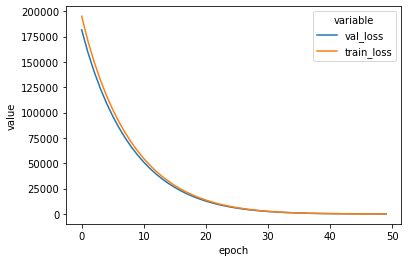

In [9]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)